In [1]:
run_gridsearch = True
skip_best_model_validation = False
skip_best_model_test = False
verbose = False

GPU_SETTING = -1
NUM_ENSEMBLES = 5
NUM_ENSEMBLES_FINAL = 1  # ensemble count for final training (validation/test)
BASIN = "warm_springs"
MODE = "daily"
RUN_LABEL = "CVTEST_V2"
READ_STAMP = "20250815T000000Z"

ADABOOST_ENSEMBLE = False
BOOTSTRAP_MODELS = False

# --- Hyperparameter Selection Method ---
use_cv_for_selection = False  # False = single-split scoring, True = CV-averaged
CV_INTERVAL_LENGTH = 2
CV_VALIDATION_LENGTH = 1
CV_INTERVAL_MONTH = 'October'


In [ ]:
hyperparam_space = {
    "hidden_size": [64, 128],
    "output_dropout": [0.4],
    "seq_length": [90, 120],
    "num_layers": [1],
    "epochs": [300],  # was [100] - plateau ES handles stopping
    "batch_size": [64],
    # "schedule_pairs": [  # plateau ES handles LR - no manual schedule needed
    #     ((0.5, 0.25), (0.01, 0.005, 0.001))
    # ]
}

In [3]:
import sys
import pandas as pd
import os
import itertools
from pathlib import Path
from tqdm import tqdm
import warnings
from datetime import datetime
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
current_dir = os.getcwd()
print(current_dir)

/Users/canruso/Desktop/UCB-USACE-RR-PROJECT/notebooks/basins/warm_springs


In [5]:
library_path = os.path.join('..', '..', '..','..','UCB-USACE-RR-PROJECT')
sys.path.insert(0, library_path)
print(sys.path)

['../../../../UCB-USACE-RR-PROJECT', '/Users/canruso/Desktop/UCB-USACE-RR-PROJECT/notebooks/basins/warm_springs', '/Users/canruso/Desktop', '/Users/canruso/miniforge3/envs/ESDL_LSTM/lib/python310.zip', '/Users/canruso/miniforge3/envs/ESDL_LSTM/lib/python3.10', '/Users/canruso/miniforge3/envs/ESDL_LSTM/lib/python3.10/lib-dynload', '', '/Users/canruso/miniforge3/envs/ESDL_LSTM/lib/python3.10/site-packages', '/Users/canruso/miniforge3/envs/ESDL_LSTM/lib/python3.10/site-packages/setuptools/_vendor']


In [6]:
from neuralhydrology.evaluation.metrics import *
from UCB_training.UCB_train import UCB_trainer
from UCB_training.UCB_utils import (fractional_multi_lr, write_paths, to_path_or_list, ensure_output_tree, set_active_context, data_dir, repo_root, get_output_dir, make_run_stamp, get_yaml_path, ctx_for, hparams_exists, save_hparams, load_hparams, runs_latest_path, archive_runs_json, read_csv_artifact, ensure_shared_tree)
from UCB_training.UCB_plotting import (plot_timeseries_comparison, scatter_triptych_pngs_v3, ts_triptych_v3)

In [7]:
current_path = os.getcwd()
library_path = current_path.split('UCB-USACE-RR-PROJECT')[0] + 'UCB-USACE-RR-PROJECT'

In [8]:
RUNS_FILE = str(runs_latest_path(BASIN, MODE, RUN_LABEL))
SHOULD_STAMP = run_gridsearch or not (skip_best_model_validation and skip_best_model_test)
RUN_STAMP = make_run_stamp() if SHOULD_STAMP else None
ACTIVE_STAMP = RUN_STAMP if RUN_STAMP is not None else READ_STAMP

In [9]:
set_active_context(basin=BASIN, resolution=MODE, run_stamp=ACTIVE_STAMP, run_tag=RUN_LABEL, append_stamp_to_filenames=False)
SHARED_FOLDER = ensure_shared_tree(BASIN, MODE)                             
RUNS_PARENT = SHARED_FOLDER / "runs" / (f"{RUN_LABEL}_{RUN_STAMP}" if RUN_STAMP else RUN_LABEL)

print("NH runs will be written under:")
print(RUNS_PARENT.resolve())

NH runs will be written under:
/Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z


In [10]:
path_to_csv = data_dir()
path_to_yaml = get_yaml_path("warm_springs_dam_nlayer")
path_to_physics_data = path_to_csv / "WarmSprings_Inflow_daily_shift.csv"

In [11]:
features_with_physics = [
    #from daily.csv
    "DRY CREEK 20 PRECIP-INC SCREENED",
    "DRY CREEK 20 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "DRY CREEK 30 PRECIP-INC SCREENED",
    "DRY CREEK 30 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "UKIAH CA HUMIDITY USAF-NOAA",
    "UKIAH CA SOLAR RADIATION USAF-NOAA",
    "UKIAH CA TEMPERATURE USAF-NOAA",
    "UKIAH CA WINDSPEED USAF-NOAA",
    "SANTA ROSA CA HUMIDITY USAF-NOAA",
    "SANTA ROSA CA SOLAR RADIATION USAF-NOAA",
    "SANTA ROSA CA TEMPERATURE USAF-NOAA",
    "SANTA ROSA CA WINDSPEED USAF-NOAA",
    #from Warm_Spring_Inflow.csv
    'Dry Creek 20 ET-POTENTIAL',
    'Dry Creek 20 FLOW',
    'Dry Creek 20 FLOW-BASE',
    'Dry Creek 20 INFILTRATION',
    'Dry Creek 20 PERC-SOIL',
    'Dry Creek 20 SATURATION FRACTION',
    'Dry Creek 30 ET-POTENTIAL',
    'Dry Creek 30 FLOW',
    'Dry Creek 30 FLOW-BASE',
    'Dry Creek 30 INFILTRATION',
    'Dry Creek 30 PERC-SOIL',
    'Dry Creek 30 SATURATION FRACTION',
    'Warm Springs Dam Inflow FLOW',
]

In [12]:
no_physics_results = []
physics_results = []

In [13]:
start_time = datetime.utcnow()
print("Start time:", start_time.strftime("%Y-%m-%d %H:%M:%S"))

Start time: 2026-01-22 09:38:00


In [14]:
import multiprocessing as mp
import itertools
import pandas as pd
from tqdm import tqdm
from UCB_training.grid_search_workers import run_single_experiment_nophysics, run_single_experiment_physics

print("run_gridsearch =", run_gridsearch)
print("hparams_exists =", hparams_exists(BASIN, MODE, RUN_LABEL))

hyperparam_names = list(hyperparam_space.keys())
total_iters = 1
for name in hyperparam_names:
    total_iters *= len(hyperparam_space[name])

if run_gridsearch or not hparams_exists(BASIN, MODE, RUN_LABEL):
    all_combinations = list(itertools.product(*[hyperparam_space[hp] for hp in hyperparam_names]))
    num_cores = max(1, mp.cpu_count() - 1)
    print(f"\n[GRID SEARCH] Spawning {num_cores} workers\n")

    # NO PHYSICS GRID SEARCH
    task_args_no = [
        (idx, comb, hyperparam_names, path_to_csv, path_to_yaml,
         GPU_SETTING, RUNS_PARENT, RUN_LABEL, RUN_STAMP, verbose,
         UCB_trainer, fractional_multi_lr, NUM_ENSEMBLES, BOOTSTRAP_MODELS, ADABOOST_ENSEMBLE,
         False, False, use_cv_for_selection, CV_INTERVAL_MONTH, CV_INTERVAL_LENGTH, CV_VALIDATION_LENGTH)
        for idx, comb in enumerate(all_combinations)
    ]
    with mp.Pool(processes=num_cores) as pool:
        no_physics_results = list(tqdm(
            pool.imap(run_single_experiment_nophysics, task_args_no),
            total=len(all_combinations), desc="Grid No-Physics", unit="it", ncols=60, ascii=True))
    df_no_physics = pd.DataFrame(no_physics_results)
    df_no_physics.sort_values(by="NSE", ascending=False, inplace=True)
    df_no_physics.reset_index(drop=True, inplace=True)
    print("\n\u2713 No-physics grid complete\n")

    # PHYSICS GRID SEARCH
    task_args_phys = [
        (idx, comb, hyperparam_names, path_to_csv, path_to_yaml,
         GPU_SETTING, RUNS_PARENT, RUN_LABEL, RUN_STAMP, verbose,
         UCB_trainer, fractional_multi_lr, NUM_ENSEMBLES, BOOTSTRAP_MODELS, ADABOOST_ENSEMBLE,
         features_with_physics, path_to_physics_data,
         False, False, use_cv_for_selection, CV_INTERVAL_MONTH, CV_INTERVAL_LENGTH, CV_VALIDATION_LENGTH)
        for idx, comb in enumerate(all_combinations)
    ]
    with mp.Pool(processes=num_cores) as pool:
        physics_results = list(tqdm(
            pool.imap(run_single_experiment_physics, task_args_phys),
            total=len(all_combinations), desc="Grid Physics", unit="it", ncols=60, ascii=True))
    df_physics = pd.DataFrame(physics_results)
    df_physics.sort_values(by="NSE", ascending=False, inplace=True)
    df_physics.reset_index(drop=True, inplace=True)
    print("\n\u2713 Physics grid complete\n")

    # save best params
    best_no_phys = df_no_physics.iloc[0].to_dict()
    best_phys = df_physics.iloc[0].to_dict()
    best_no_phys["model_type"] = "no_physics"
    best_phys["model_type"] = "physics"
    best_params_df = pd.DataFrame([best_no_phys, best_phys])
    save_hparams(best_df=best_params_df, basin=BASIN, mode=MODE, label=RUN_LABEL, run_stamp=RUN_STAMP, df_no=df_no_physics, df_phys=df_physics)
else:
    print("Skipping grid search!")

print("run_gridsearch =", run_gridsearch)
print("hparams_exists =", hparams_exists(BASIN, MODE, RUN_LABEL))

Grid-Search:   0%|                   | 0/54 [00:00<?, ?it/s]

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_123800/fold_01/testing_run_2201_123800/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_123800/fold_02/testing_run_2201_123808/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_123800/fold_03/testing_run_2201_123818/loss_curves.png


Grid-Search:   2%|2          | 1/54 [00:52<46:23, 52.51s/it]

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_123800/fold_04/testing_run_2201_123834/loss_curves.png
{'avg NSE': 0.8182099871337414, 'avg MSE': 114574.455078125, 'avg RMSE': 318.928162962105, 'avg KGE': 0.7058081773309854, 'avg Alpha-NSE': 1.0553752313360008, 'avg Beta-KGE': 1.2364023923873901, 'avg Beta-NSE': 0.10535060206535393, 'avg Pearson-r': 0.9304967433296458, 'avg FHV': 8.777634613215923, 'avg FMS': 130.97207845401232, 'avg FLV': -3274.743094945534, 'avg Peak-Timing': 0.375, 'avg Peak-MAPE': 20.20796751603484}
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_123852/fold_01/testing_run_2201_123852/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_123852/f

Grid-Search:   4%|4          | 2/54 [01:34<40:08, 46.33s/it]

...

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_144408/fold_04/testing_run_2201_144919/loss_curves.png
{'avg NSE': 0.8078382015228271, 'avg MSE': 126366.16748046875, 'avg RMSE': 324.9681576559175, 'avg KGE': 0.7032180484631718, 'avg Alpha-NSE': 1.0449952151002568, 'avg Beta-KGE': 1.116326317191124, 'avg Beta-NSE': 0.058712784851351306, 'avg Pearson-r': 0.9393221731820369, 'avg FHV': 6.5115733072161674, 'avg FMS': 107.44689877155366, 'avg FLV': -3590.322858483567, 'avg Peak-Timing': 0.375, 'avg Peak-MAPE': 23.82713770493865}
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_145237/fold_01/testing_run_2201_145237/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_1452

Grid-Search:  98%|######8| 53/54 [2:21:47<06:00, 360.71s/it]

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_145237/fold_04/testing_run_2201_145651/loss_curves.png
{'avg NSE': 0.8245322927832603, 'avg MSE': 139345.18798828125, 'avg RMSE': 331.37179040161965, 'avg KGE': 0.7019029188457089, 'avg Alpha-NSE': 0.9614021160690647, 'avg Beta-KGE': 1.1400839239358902, 'avg Beta-NSE': 0.0691687352079371, 'avg Pearson-r': 0.9351236325635306, 'avg FHV': -1.8432257696986198, 'avg FMS': 101.50617211224126, 'avg FLV': -2658.739488634609, 'avg Peak-Timing': 0.375, 'avg Peak-MAPE': 28.95946541102603}
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_145947/fold_01/testing_run_2201_145947/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_145

Grid-Search: 100%|#######| 54/54 [2:28:16<00:00, 164.75s/it]

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_145947/fold_04/testing_run_2201_150343/loss_curves.png
{'avg NSE': 0.7718473896384239, 'avg MSE': 172691.759765625, 'avg RMSE': 374.2621021485396, 'avg KGE': 0.6428492747160313, 'avg Alpha-NSE': 1.0051213483695518, 'avg Beta-KGE': 1.137902483344078, 'avg Beta-NSE': 0.07146313089576127, 'avg Pearson-r': 0.9255123852791958, 'avg FHV': 1.9685528241097927, 'avg FMS': 97.08274316080346, 'avg FLV': -2177.4919126336995, 'avg Peak-Timing': 0.375, 'avg Peak-MAPE': 29.791750945150852}


In [15]:
# Physics grid search merged into cell above

Grid-Search:   0%|                   | 0/54 [00:00<?, ?it/s]

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_150616/fold_01/testing_run_2201_150616/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_150616/fold_02/testing_run_2201_150624/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_150616/fold_03/testing_run_2201_150636/loss_curves.png


Grid-Search:   2%|2          | 1/54 [00:54<47:54, 54.24s/it]

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_150616/fold_04/testing_run_2201_150652/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_150710/fold_01/testing_run_2201_150710/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_150710/fold_02/testing_run_2201_150719/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_150710/fold_03/testing_run_2201_150729/loss_curves.png


Grid-Search:   4%|4          | 2/54 [01:41<43:30, 50.20s/it]

...

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_170900/fold_04/testing_run_2201_171306/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_171544/fold_01/testing_run_2201_171544/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_171544/fold_02/testing_run_2201_171617/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_171544/fold_03/testing_run_2201_171727/loss_curves.png


Grid-Search:  98%|######8| 53/54 [2:14:54<04:42, 282.25s/it]

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_171544/fold_04/testing_run_2201_171900/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_172110/fold_01/testing_run_2201_172110/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_172110/fold_02/testing_run_2201_172142/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_172110/fold_03/testing_run_2201_172248/loss_curves.png


Grid-Search: 100%|#######| 54/54 [2:19:55<00:00, 155.47s/it]

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/cross_validation_2201_172110/fold_04/testing_run_2201_172415/loss_curves.png


In [16]:
try:
    if run_gridsearch:
        print("\n[INFO] Using best_params_df from the just-completed grid search (ignoring READ_STAMP).")
    else:
        print("\nLoading best hyperparams from CSV...")
        best_params_df = load_hparams(BASIN, MODE, RUN_LABEL, stamp=READ_STAMP)
except FileNotFoundError as e:
    raise SystemExit(f"[ERROR] {e}  (Set run_gridsearch=True to generate it.)")

best_no_phys = best_params_df.query("model_type == 'no_physics'").iloc[0].to_dict()
best_phys = best_params_df.query("model_type == 'physics'").iloc[0].to_dict()

best_no_physics_params = {}
j = 0
while j < len(hyperparam_names):
    name = hyperparam_names[j]
    if name == "output_dropout":
        best_no_physics_params[name] = float(best_no_phys[name])
        j += 1

    elif name == "seq_length":
        best_no_physics_params["seq_length"] = int(best_no_phys["seq_length"])
        j += 1

    elif name == "schedule_pairs":
        j += 1

    else:
        best_no_physics_params[name] = int(best_no_phys[name])
        j += 1

if "learning_rate" in best_no_phys and pd.notna(best_no_phys["learning_rate"]):
    best_no_physics_params["learning_rate"] = eval(str(best_no_phys["learning_rate"]))

elif "schedule_pairs" in best_no_phys and pd.notna(best_no_phys["schedule_pairs"]):
    sp = best_no_phys["schedule_pairs"]
    if isinstance(sp, str):
        sp = eval(sp)
    fractions, rates = sp
    best_no_physics_params["learning_rate"] = fractional_multi_lr(
        epochs=int(best_no_physics_params["epochs"]),
        fractions=list(fractions),
        lrs=list(rates))

else:
    best_no_physics_params["learning_rate"] = {0: 0.01, 30: 0.005, 40: 0.001}

best_physics_params = {}
j = 0
while j < len(hyperparam_names):
    name = hyperparam_names[j]
    if name == "output_dropout":
        best_physics_params[name] = float(best_phys[name])
        j += 1

    elif name == "seq_length":
        best_physics_params["seq_length"] = int(best_phys["seq_length"])
        j += 1

    elif name == "schedule_pairs":
        j += 1

    else:
        best_physics_params[name] = int(best_phys[name])
        j += 1

if "learning_rate" in best_phys and pd.notna(best_phys["learning_rate"]):
    best_physics_params["learning_rate"] = eval(str(best_phys["learning_rate"]))

elif "schedule_pairs" in best_phys and pd.notna(best_phys["schedule_pairs"]):
    sp = best_phys["schedule_pairs"]
    if isinstance(sp, str):
        sp = eval(sp)
    fractions, rates = sp
    best_physics_params["learning_rate"] = fractional_multi_lr(
        epochs=int(best_physics_params["epochs"]),
        fractions=list(fractions),
        lrs=list(rates))

else:
    best_physics_params["learning_rate"] = {0: 0.01, 30: 0.005, 40: 0.001}

print("Loaded best hyperparams from CSV:")
print("Best NO-PHYS:", best_no_physics_params)
print("Best PHYS:", best_physics_params)


[INFO] Using best_params_df from the just-completed grid search (ignoring READ_STAMP).
Loaded best hyperparams from CSV:
Best NO-PHYS: {'hidden_size': 128, 'output_dropout': 0.4, 'seq_length': 90, 'num_layers': 1, 'epochs': 48, 'batch_size': 64, 'learning_rate': {0: 0.01, 24: 0.005, 36: 0.001}}
Best PHYS: {'hidden_size': 128, 'output_dropout': 0.4, 'seq_length': 90, 'num_layers': 1, 'epochs': 32, 'batch_size': 64, 'learning_rate': {0: 0.01, 16: 0.005, 24: 0.001}}


### Re-run validation with best hyperparameters

In [17]:
if not skip_best_model_validation:
    lstmNoPhysicsValBest = UCB_trainer(
        path_to_csv_folder=path_to_csv,
        yaml_path=path_to_yaml,
        hyperparams=best_no_physics_params,
        input_features=None,
        physics_informed=False,
        physics_data_file=None,
        hourly=False,
        extend_train_period=False,
        gpu=GPU_SETTING,
        # num_ensemble_members = NUM_ENSEMBLES_FINAL,
        verbose=verbose,
        runs_parent=RUNS_PARENT,
        run_label=RUN_LABEL,
        run_stamp=RUN_STAMP)
    
    lstmNoPhysicsValBest.train()
    no_physics_val_csv, no_physics_val_metrics = lstmNoPhysicsValBest.results()
    no_physics_val_metrics

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/testing_run_2201_172611/loss_curves.png


In [18]:
if not skip_best_model_validation:
    lstmPhysicsValBest = UCB_trainer(
        path_to_csv_folder=path_to_csv,
        yaml_path=path_to_yaml,
        hyperparams=best_physics_params,
        input_features=features_with_physics,
        physics_informed=True,
        physics_data_file=path_to_physics_data,
        hourly=False,
        extend_train_period=False,
        gpu=GPU_SETTING,
        # num_ensemble_members = NUM_ENSEMBLES_FINAL,
        verbose=verbose,
        runs_parent=RUNS_PARENT,
        run_label=RUN_LABEL,
        run_stamp=RUN_STAMP)
    
    lstmPhysicsValBest.train()
    physics_val_csv, physics_val_metrics = lstmPhysicsValBest.results()
    physics_val_metrics

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/testing_run_2201_172714/loss_curves.png


HMS
  NSE = 0.696
  PBIAS = -8.727
LSTM
  NSE = 0.829
  PBIAS = -4.464
PILSTM
  NSE = 0.833
  PBIAS = -11.372


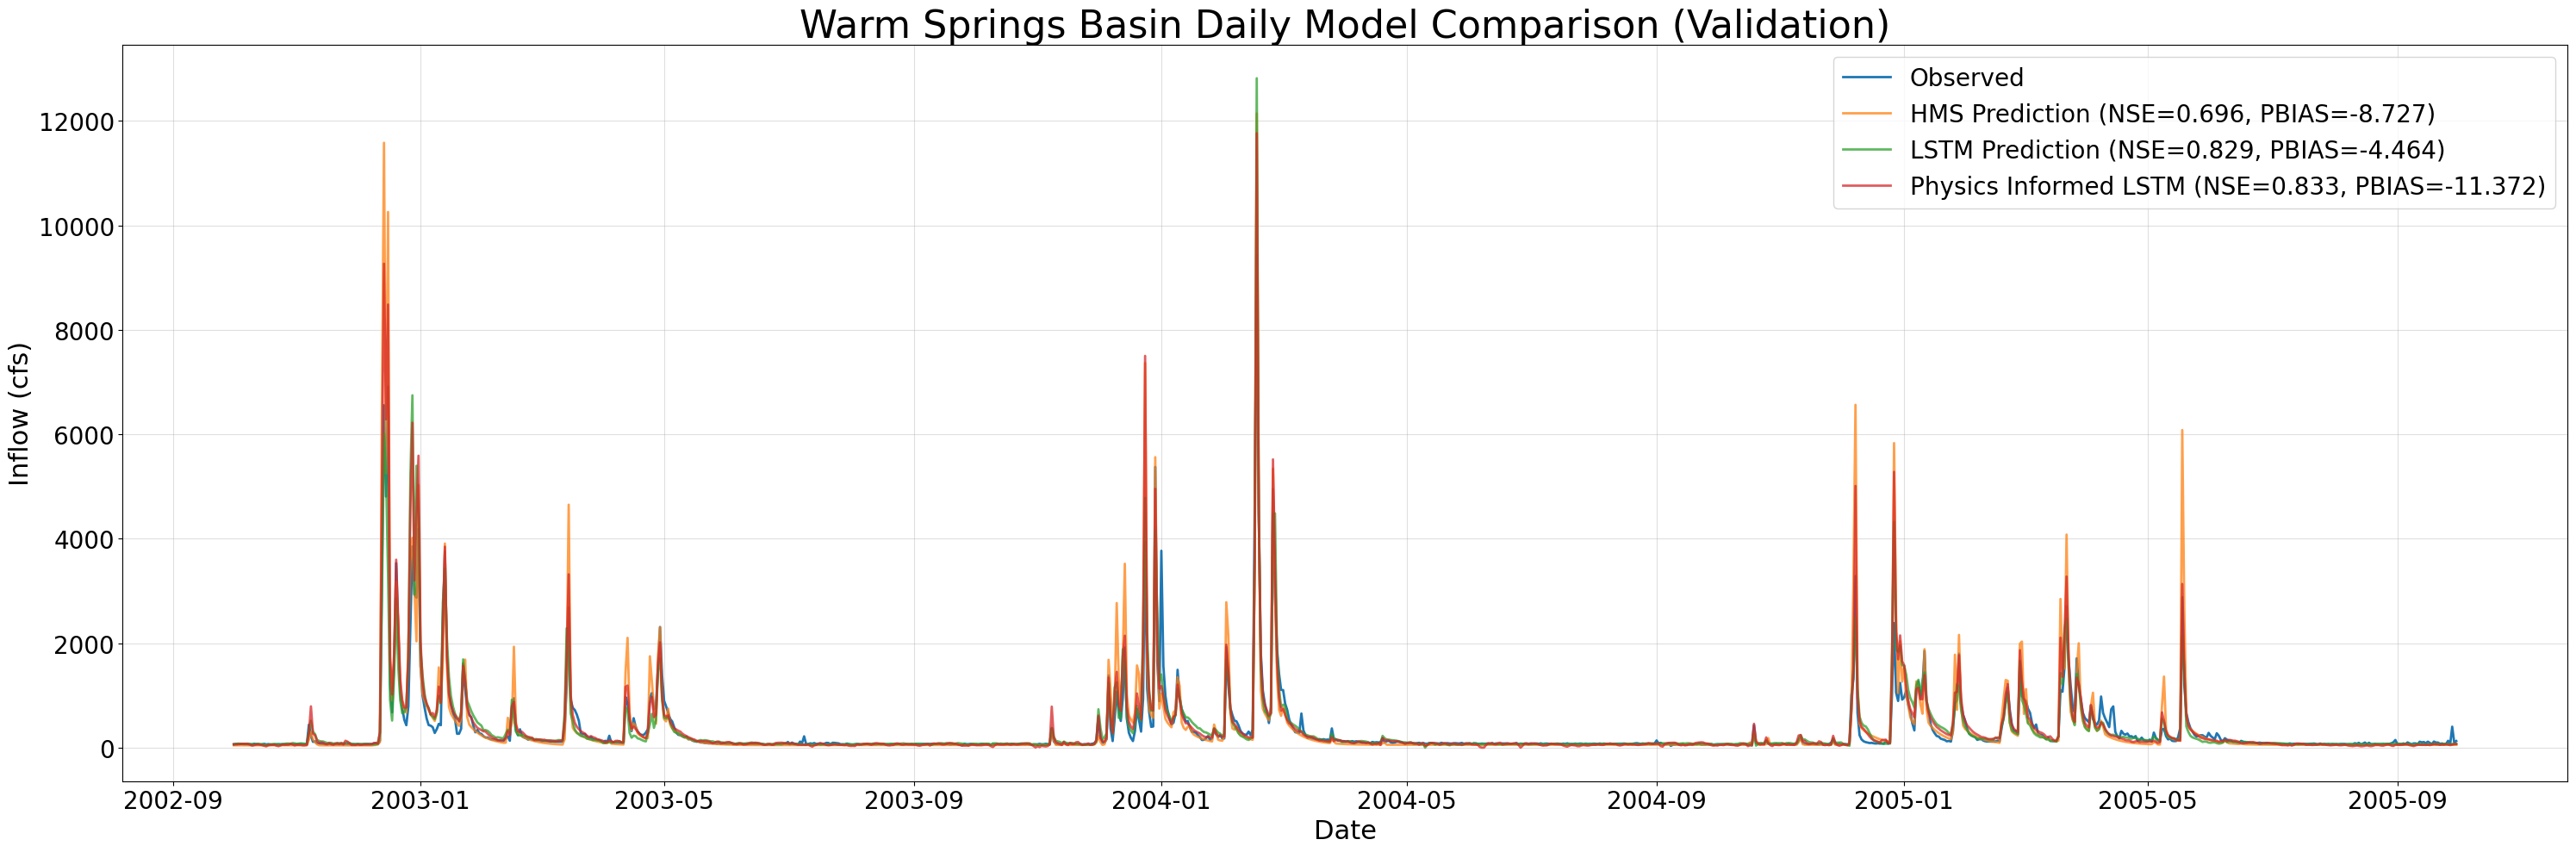

In [19]:
if not skip_best_model_validation:
    plot_timeseries_comparison(source=(no_physics_val_csv, physics_val_csv, path_to_physics_data), title="Warm Springs Basin Daily Model Comparison (Validation)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="warm_springs_daily_val_metrics.csv", ts_out="warm_springs_daily_val_combined_ts.csv", fig_out="warm_springs_daily_val_model_comparison.png", legend_font=20, axis_font=22)
else:
    combined_df_val = read_csv_artifact("warm_springs_daily_val_combined_ts.csv", kind="csv", period="validation", stamp = READ_STAMP, run_label = RUN_LABEL)
    plot_timeseries_comparison(source=combined_df_val, title="Warm Springs Basin Daily Model Comparison (Validation)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="warm_springs_daily_val_metrics.csv", ts_out="warm_springs_daily_val_combined_ts.csv", fig_out="warm_springs_daily_val_model_comparison.png", legend_font=20, axis_font=22)

In [20]:
if skip_best_model_validation:
    val_metrics = read_csv_artifact("warm_springs_daily_val_metrics.csv", kind="metrics", period="validation", index_col=0, stamp = READ_STAMP, run_label = RUN_LABEL)
    print(val_metrics)

### Re-run testing with best hyperparameters

In [21]:
if not skip_best_model_test:
    lstmNoPhysicsExtBest = UCB_trainer(
        path_to_csv_folder=path_to_csv,
        yaml_path=path_to_yaml,
        hyperparams=best_no_physics_params,
        input_features=None,
        physics_informed=False,
        physics_data_file=None,
        hourly=False,
        extend_train_period=True,  
        gpu=GPU_SETTING,
        # num_ensemble_members = NUM_ENSEMBLES_FINAL,
        verbose=verbose,
        runs_parent=RUNS_PARENT,
        run_label=RUN_LABEL,
        run_stamp=RUN_STAMP)
    
    lstmNoPhysicsExtBest.train()
    no_physics_test_csv, no_physics_test_metrics = lstmNoPhysicsExtBest.results('test')
    no_physics_test_metrics

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/testing_run_2201_172803/loss_curves.png


In [22]:
if not skip_best_model_test:
    lstmPhysicsExtBest = UCB_trainer(
        path_to_csv_folder=path_to_csv,
        yaml_path=path_to_yaml,
        hyperparams=best_physics_params,
        input_features=features_with_physics,
        physics_informed=True,
        physics_data_file=path_to_physics_data,
        hourly=False,
        extend_train_period=True,
        gpu=GPU_SETTING,
        # num_ensemble_members = NUM_ENSEMBLES_FINAL,
        verbose=verbose,
        runs_parent=RUNS_PARENT,
        run_label=RUN_LABEL,
        run_stamp=RUN_STAMP)
    
    lstmPhysicsExtBest.train()
    physics_test_csv, physics_test_metrics = lstmPhysicsExtBest.results('test')
    physics_test_metrics

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/warm_springs/daily_shared/runs/CVTEST_V2_20260122T093800Z/testing_run_2201_172929/loss_curves.png


HMS
  NSE = 0.732
  PBIAS = -3.817
LSTM
  NSE = 0.855
  PBIAS = -0.598
PILSTM
  NSE = 0.878
  PBIAS = -3.312


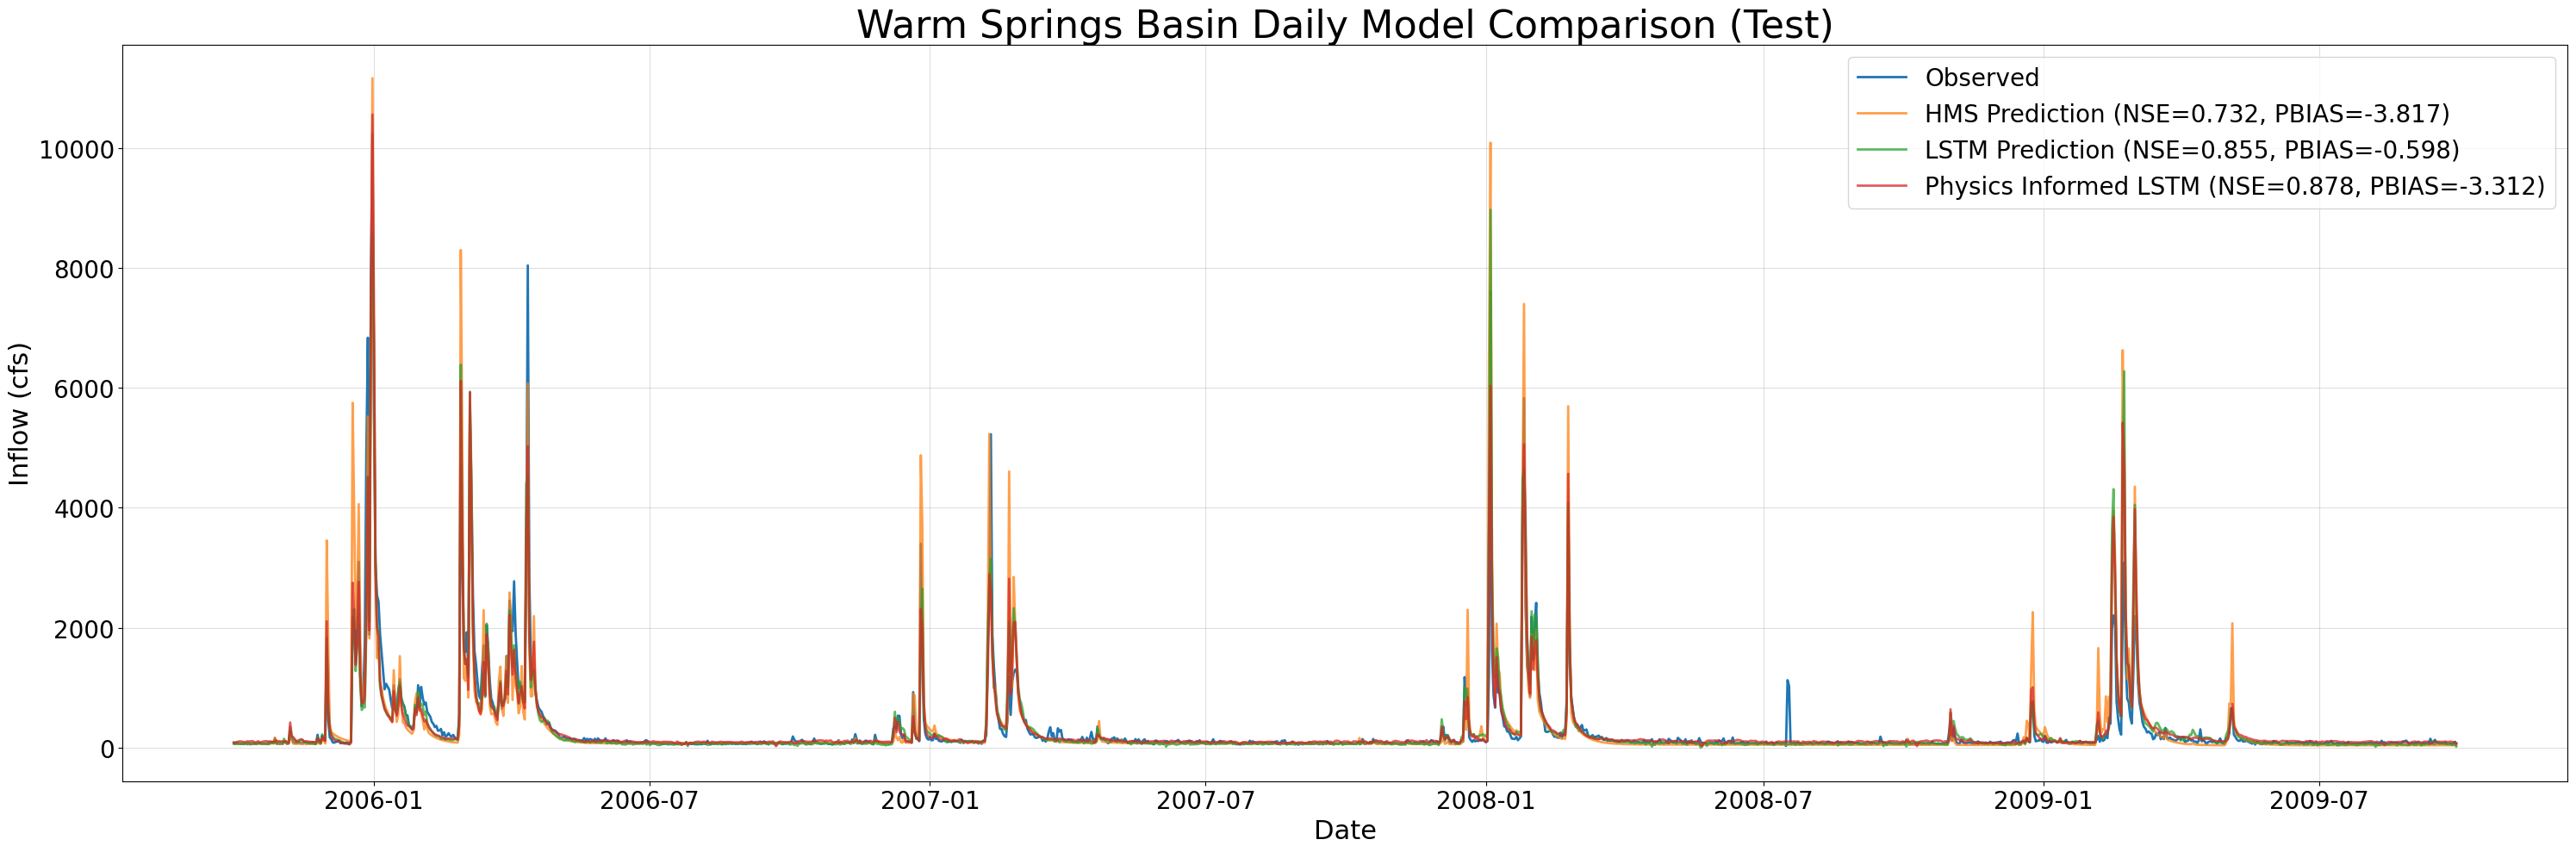

In [23]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv, physics_test_csv, path_to_physics_data), title="Warm Springs Basin Daily Model Comparison (Test)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="warm_springs_daily_test_metrics.csv", ts_out="warm_springs_daily_test_combined_ts.csv", fig_out="warm_springs_daily_model_comparison.png", legend_font=20, axis_font=22)
else:
    combined_df = read_csv_artifact("warm_springs_daily_test_combined_ts.csv", kind="csv", period="test", stamp = READ_STAMP, run_label = RUN_LABEL)
    plot_timeseries_comparison(source=combined_df, title="Warm Springs Basin Daily Model Comparison (Test)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="warm_springs_daily_test_metrics.csv", ts_out="warm_springs_daily_test_combined_ts.csv", fig_out="warm_springs_daily_model_comparison.png", legend_font=20, axis_font=22)

In [24]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv, physics_test_csv, path_to_physics_data), title="Warm Springs Basin Daily Model Comparison (Test)", backend="plotly", metrics=["NSE", "PBIAS"], metrics_out="warm_springs_daily_test_metrics.csv", ts_out="warm_springs_daily_test_combined_ts.csv", fig_out="warm_springs_daily_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df, title="Warm Springs Basin Daily Model Comparison (Test)", backend="plotly", metrics=["NSE", "PBIAS"], metrics_out="warm_springs_daily_test_metrics.csv", ts_out="warm_springs_daily_test_combined_ts.csv", fig_out="warm_springs_daily_model_comparison.png", legend_font=12, axis_font=22)

HMS
  NSE = 0.732
  PBIAS = -3.817
LSTM
  NSE = 0.855
  PBIAS = -0.598
PILSTM
  NSE = 0.878
  PBIAS = -3.312


In [25]:
test_metrics = read_csv_artifact("warm_springs_daily_test_metrics.csv", kind="metrics", period="test", index_col=0, stamp = READ_STAMP, run_label = RUN_LABEL)
print(test_metrics)

                       HMS          LSTM        PILSTM
NSE               0.732375      0.854609      0.877741
MSE          143312.877184  77857.061677  65469.778899
RMSE            378.566873    279.028783    255.870629
KGE               0.791169      0.927232      0.925667
Alpha-NSE         1.179486      1.007835      0.976421
Beta-KGE          1.038166      1.005982      1.033123
Beta-NSE          0.015523      0.002433      0.013472
Pearson-r         0.900309      0.927903      0.937772
FHV              24.454837      4.219092      0.962414
FMS              25.219424     25.342734    -17.906033
FLV              79.322057  -2224.084738    -65.180242
Peak-Timing       0.833333      0.333333      0.666667
Peak-MAPE        44.995233     52.513781     42.409182
PBIAS            -3.816588     -0.598153     -3.312288


In [ ]:
if not skip_best_model_validation:
    write_paths("no_physics_val", lstmNoPhysicsValBest, filename = RUNS_FILE)
    write_paths("physics_val", lstmPhysicsValBest, filename = RUNS_FILE)

if not skip_best_model_test:
    write_paths("no_physics", lstmNoPhysicsExtBest, filename = RUNS_FILE)
    write_paths("physics", lstmPhysicsExtBest, filename = RUNS_FILE)
    archived_path = archive_runs_json(Path(RUNS_FILE), BASIN, MODE, RUN_LABEL, RUN_STAMP)

In [27]:
end_time = datetime.utcnow()
print("\nEnd time:", end_time.strftime("%Y-%m-%d %H:%M:%S"))
print("Total time:", end_time - start_time)


End time: 2026-01-22 14:30:38
Total time: 4:52:38.607004


##### Additional Plots

In [28]:
if skip_best_model_validation:
    combined_df_val = read_csv_artifact("warm_springs_daily_val_combined_ts.csv", kind="csv", period="validation", stamp = READ_STAMP, run_label = RUN_LABEL)
if skip_best_model_test:
    combined_df = read_csv_artifact("warm_springs_daily_test_combined_ts.csv", kind="csv", period="test", stamp = READ_STAMP, run_label = RUN_LABEL)

In [29]:
metric_list = ["NSE", "PBIAS"]

wettest_start_val = "2003-10-01"
wettest_end_val = "2004-09-30"
dryest_start_val = "2004-10-01"
dryest_end_val = "2005-09-30"
wettest_start_test = "2005-10-01"
wettest_end_test = "2006-09-30"
dryest_start_test = "2008-10-01"
dryest_end_test = "2009-09-30"

HMS
  NSE = 0.696
  PBIAS = -8.727
LSTM
  NSE = 0.829
  PBIAS = -4.464
PILSTM
  NSE = 0.833
  PBIAS = -11.372


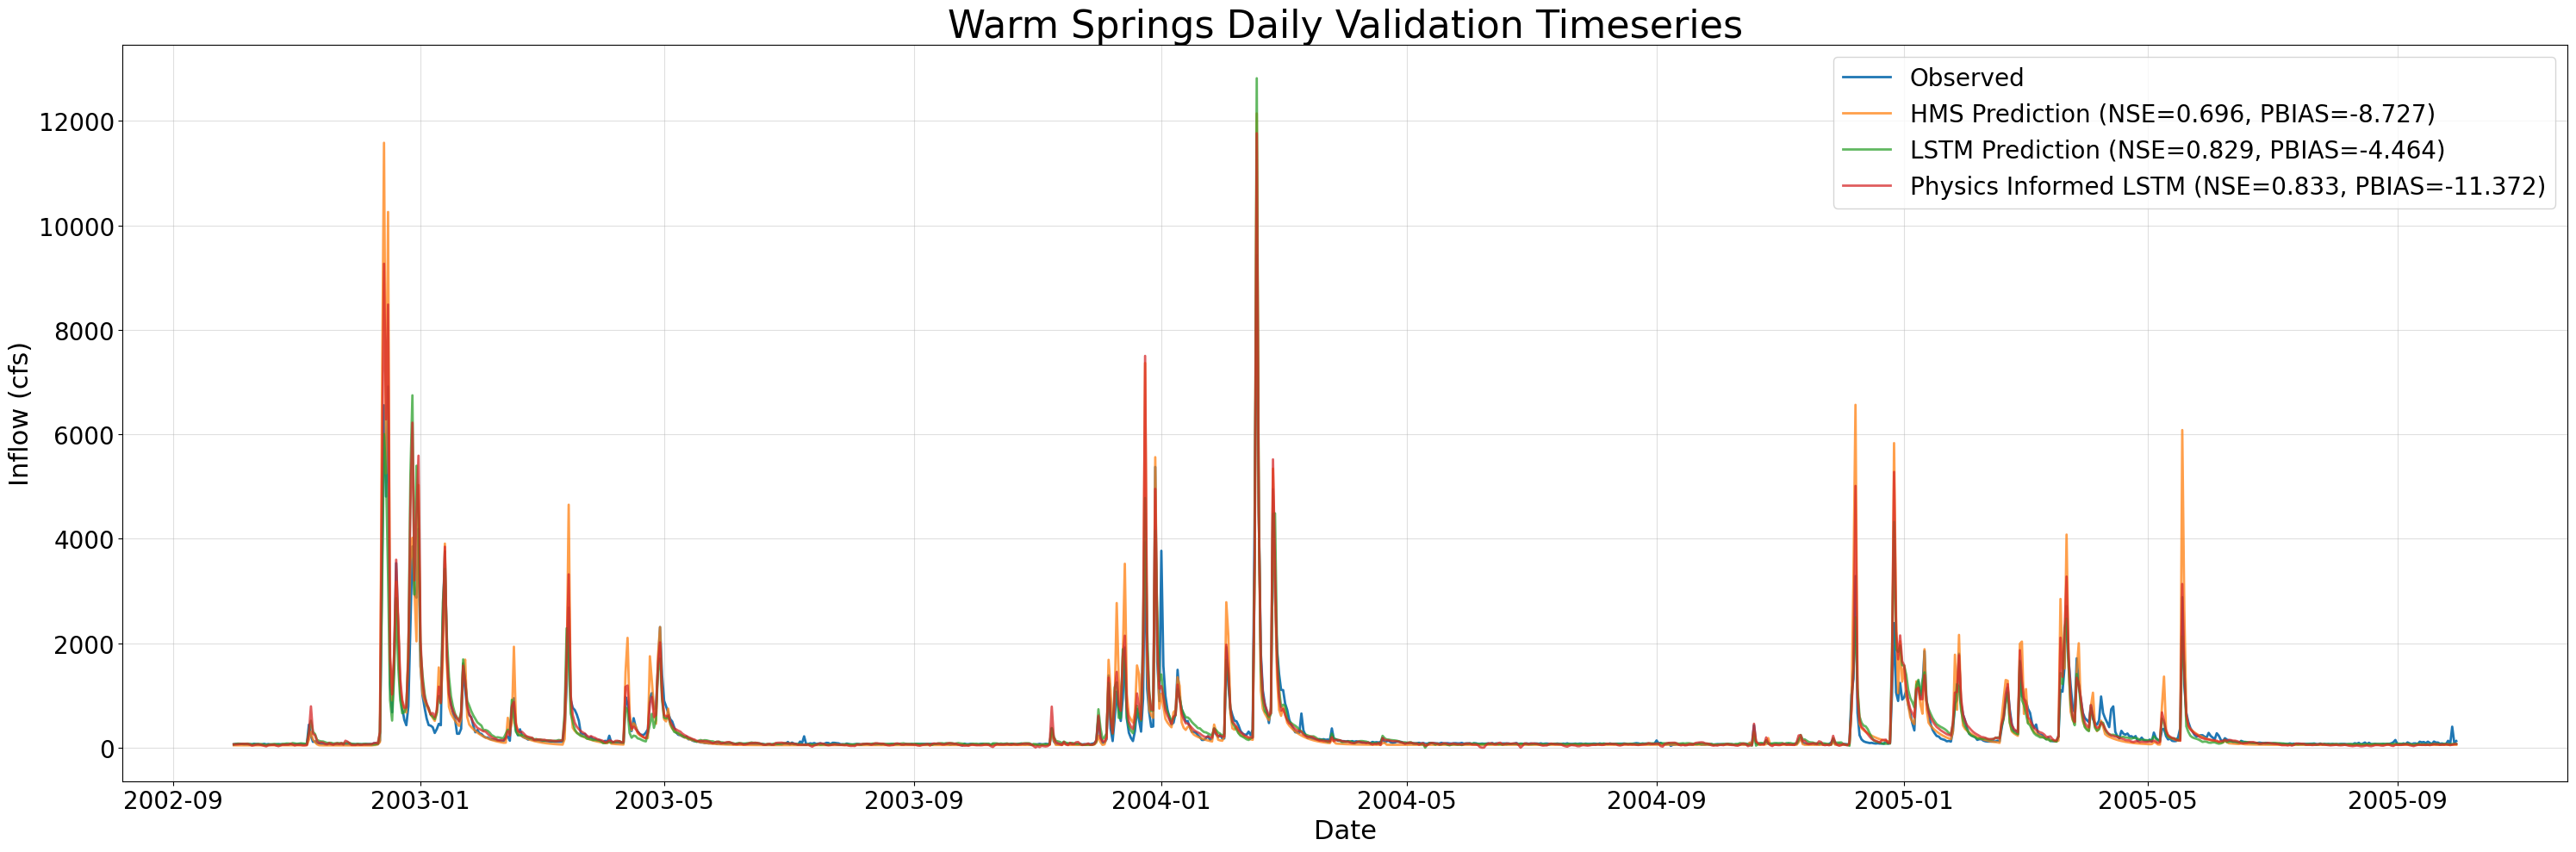

In [30]:
if not skip_best_model_validation:
    plot_timeseries_comparison(source=(no_physics_val_csv, physics_val_csv, path_to_physics_data), title="Warm Springs Daily Validation Timeseries", backend="mpl", metrics=metric_list, metrics_out="warm_springs_daily_val_metrics.csv", ts_out="warm_springs_daily_val_combined_ts.csv", fig_out="warm_springs_daily_val_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_val, title="Warm Springs Daily Validation Timeseries", backend="mpl", metrics=metric_list, metrics_out="warm_springs_daily_val_metrics.csv", ts_out="warm_springs_daily_val_combined_ts.csv", fig_out="warm_springs_daily_val_model_comparison.png", legend_font=20, axis_font=22)

HMS
  NSE = 0.732
  PBIAS = -3.817
LSTM
  NSE = 0.855
  PBIAS = -0.598
PILSTM
  NSE = 0.878
  PBIAS = -3.312


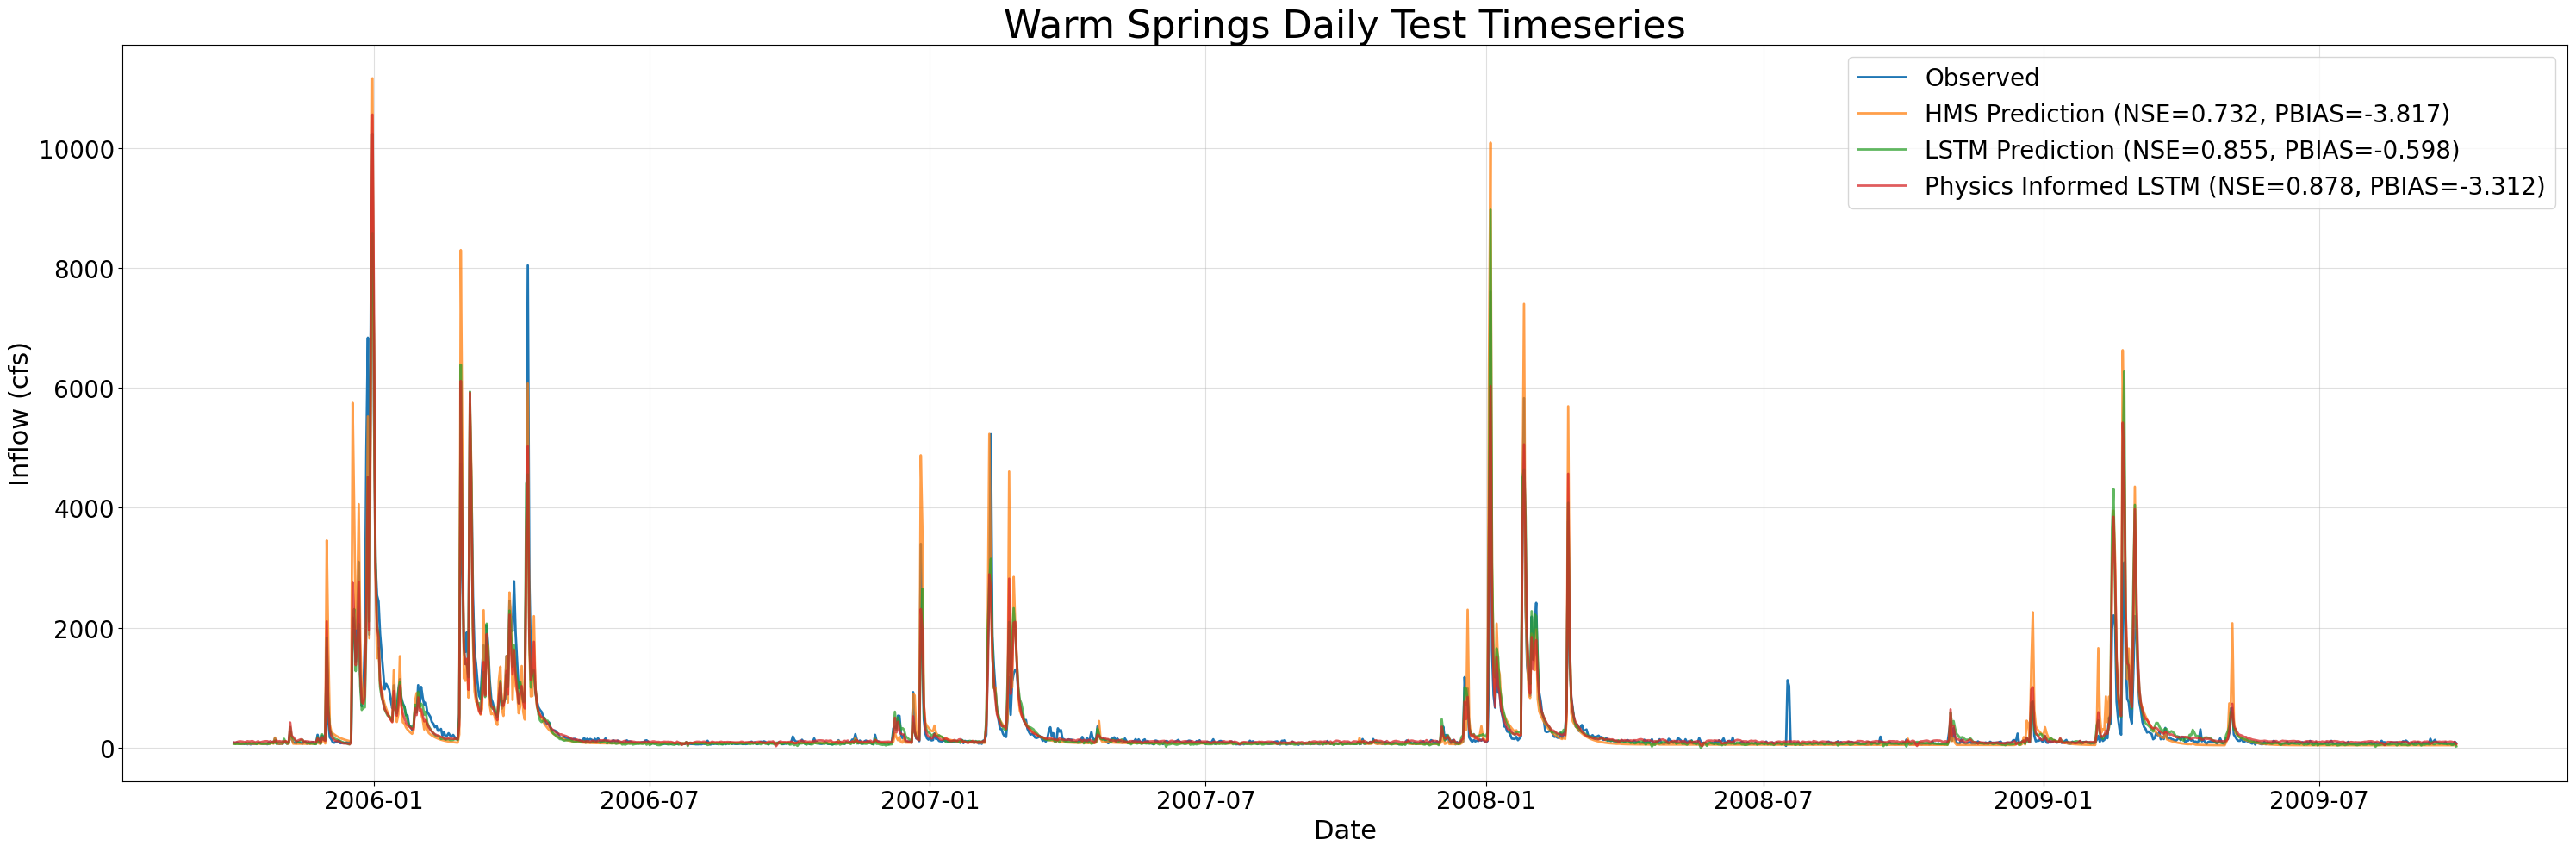

In [31]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv, physics_test_csv, path_to_physics_data), title="Warm Springs Daily Test Timeseries", backend="mpl", metrics=metric_list, metrics_out="warm_springs_daily_test_metrics.csv", ts_out="warm_springs_daily_test_combined_ts.csv", fig_out="warm_springs_daily_test_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df, title="Warm Springs Daily Test Timeseries", backend="mpl", metrics=metric_list, metrics_out="warm_springs_daily_test_metrics.csv", ts_out="warm_springs_daily_test_combined_ts.csv", fig_out="warm_springs_daily_test_model_comparison.png", legend_font=20, axis_font=22)

In [32]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv, physics_test_csv, path_to_physics_data), title="Warm Springs Daily Test Timeseries – Interactive", backend="plotly", metrics=metric_list, metrics_out="warm_springs_daily_test_metrics.csv", ts_out="warm_springs_daily_test_combined_ts.csv", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df, title="Warm Springs Daily Test Timeseries – Interactive", backend="plotly", metrics=metric_list, metrics_out="warm_springs_daily_test_metrics.csv", ts_out="warm_springs_daily_test_combined_ts.csv", fig_out="warm_springs_daily_test_model_comparison.png", legend_font=12, axis_font=22)

HMS
  NSE = 0.732
  PBIAS = -3.817
LSTM
  NSE = 0.855
  PBIAS = -0.598
PILSTM
  NSE = 0.878
  PBIAS = -3.312


##### Wettest Year Performance

HMS
  NSE = 0.817
  PBIAS = -1.539
LSTM
  NSE = 0.869
  PBIAS = -5.688
PILSTM
  NSE = 0.863
  PBIAS = -4.413


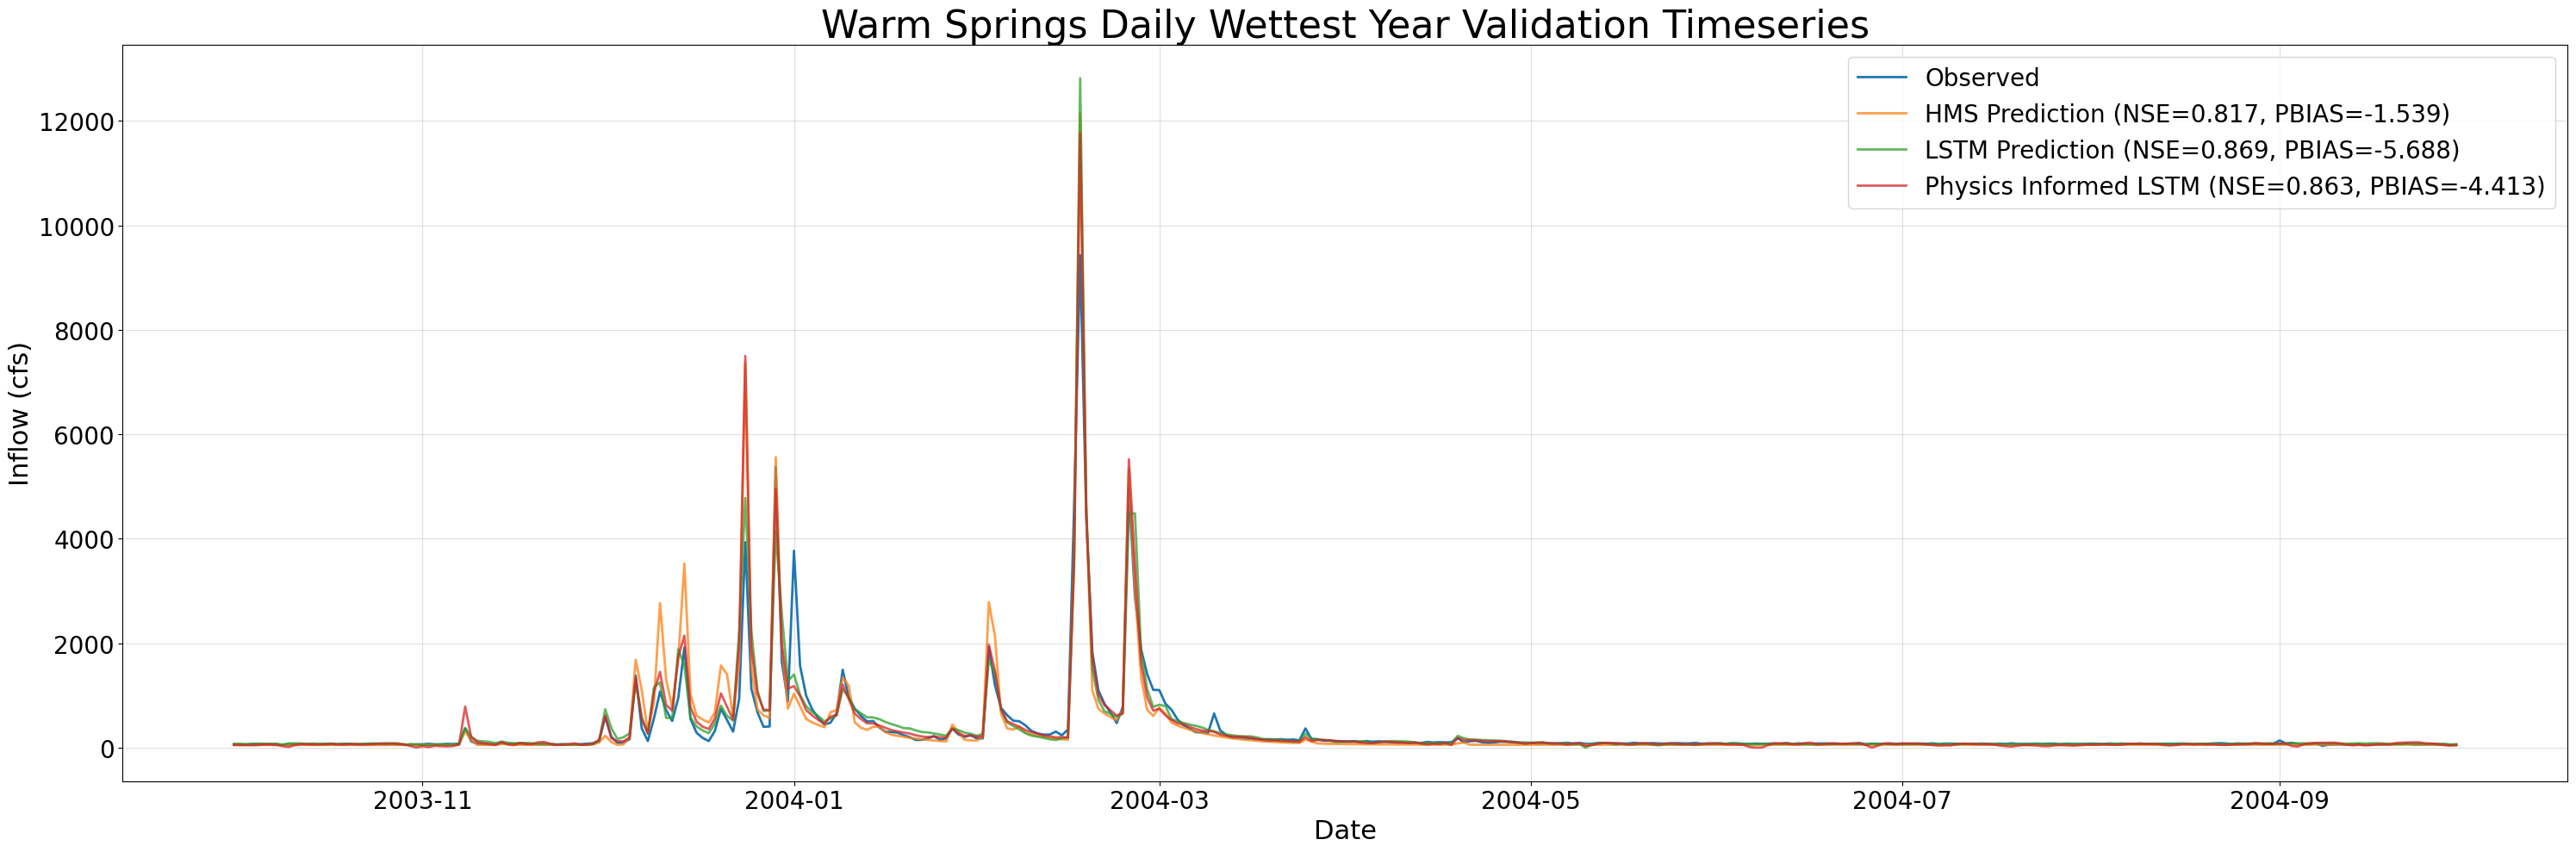

In [33]:
if not skip_best_model_validation:
    plot_timeseries_comparison(source=(no_physics_val_csv, physics_val_csv, path_to_physics_data), title="Warm Springs Daily Wettest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_val, end_date=wettest_end_val, metrics_out="warm_springs_daily_val_wet_metrics.csv", ts_out="warm_springs_daily_val_wet_combined_ts.csv", fig_out="warm_springs_daily_val_wet_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_val, title="Warm Springs Daily Wettest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_val, end_date=wettest_end_val, metrics_out="warm_springs_daily_val_wet_metrics.csv", ts_out="warm_springs_daily_val_wet_combined_ts.csv", fig_out="warm_springs_daily_val_wet_model_comparison.png", legend_font=20, axis_font=22)

HMS
  NSE = 0.848
  PBIAS = 7.771
LSTM
  NSE = 0.904
  PBIAS = 13.870
PILSTM
  NSE = 0.918
  PBIAS = 10.803


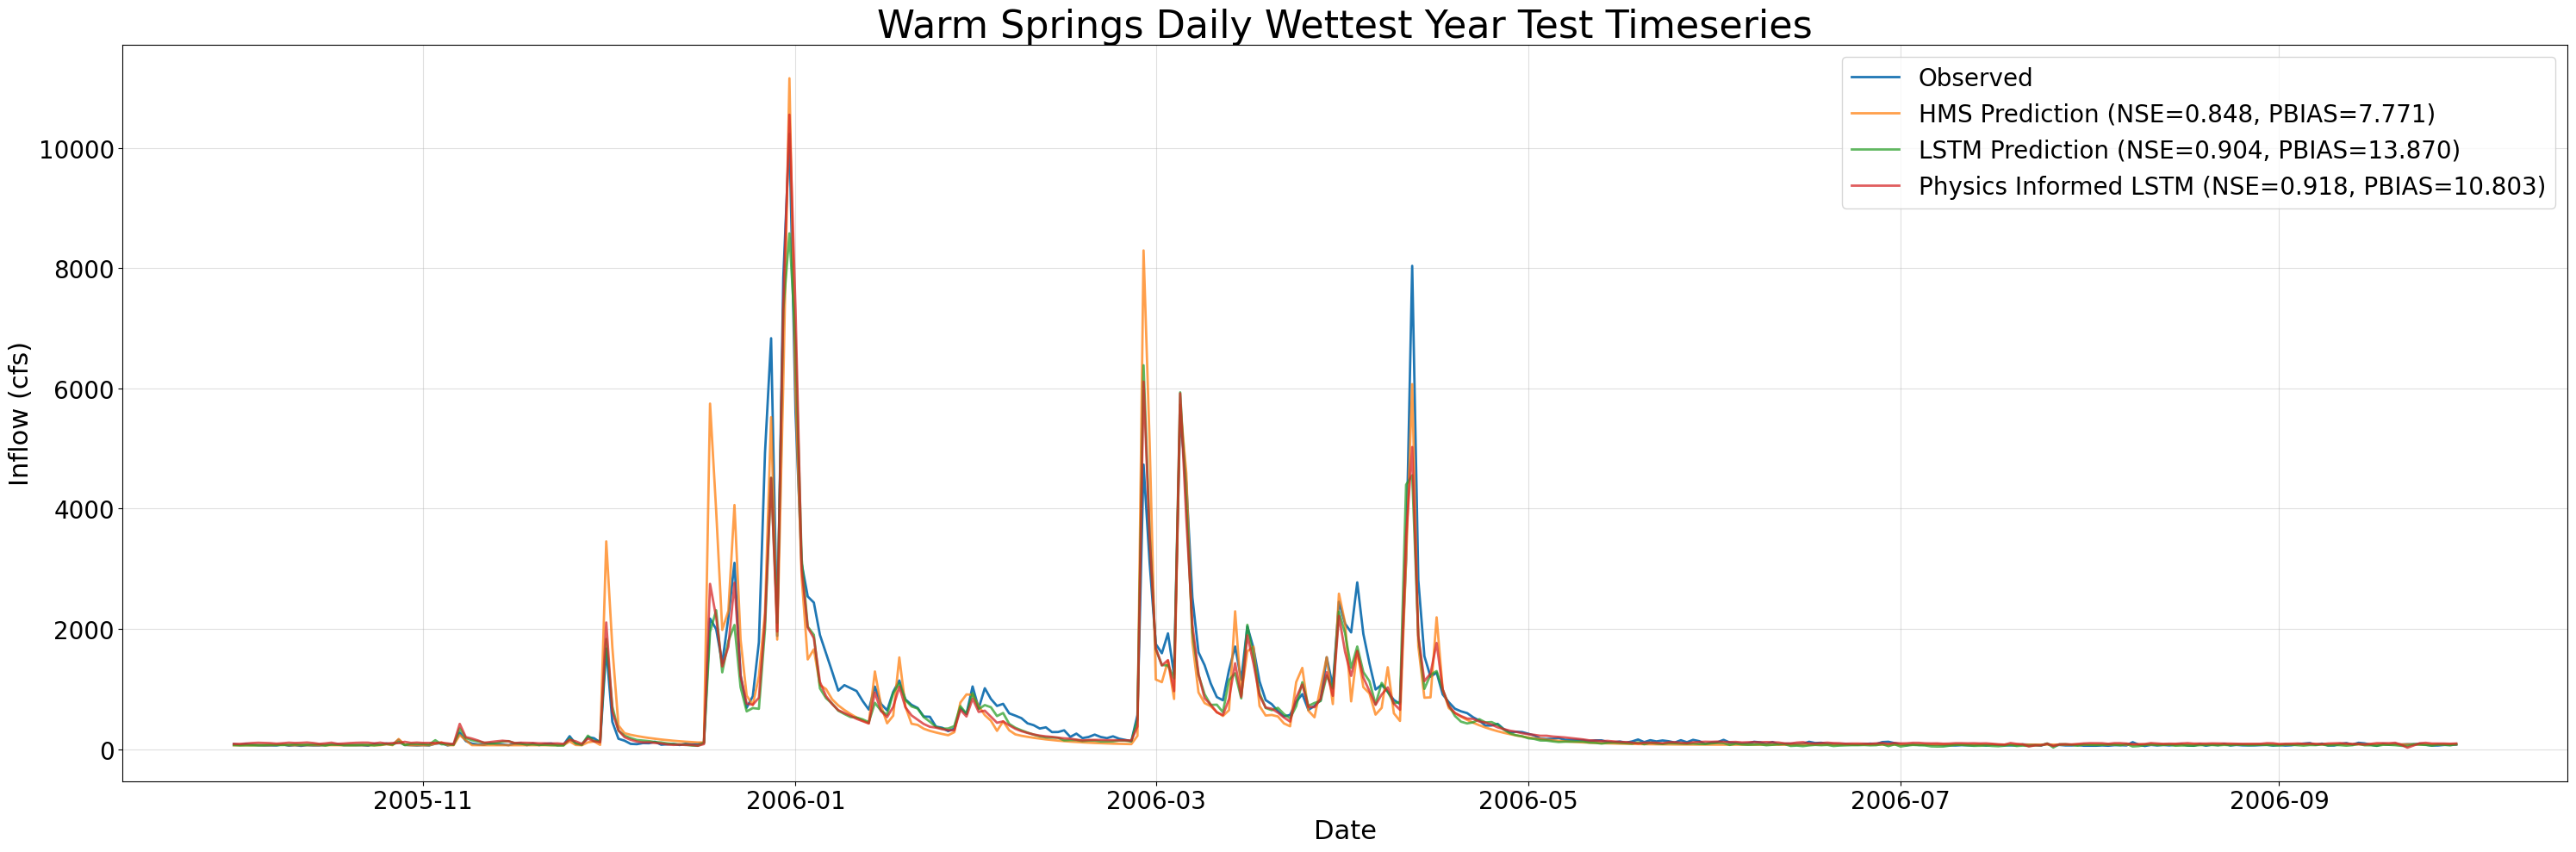

In [34]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv, physics_test_csv, path_to_physics_data), title="Warm Springs Daily Wettest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="warm_springs_daily_test_wet_metrics.csv", ts_out="warm_springs_daily_test_wet_combined_ts.csv", fig_out="warm_springs_daily_test_wet_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df, title="Warm Springs Daily Wettest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="warm_springs_daily_test_wet_metrics.csv", ts_out="warm_springs_daily_test_wet_combined_ts.csv", fig_out="warm_springs_daily_test_wet_model_comparison.png", legend_font=20, axis_font=22)

In [35]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv, physics_test_csv, path_to_physics_data), title="Warm Springs Daily Wettest Year Test Timeseries – Interactive", backend="plotly", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="warm_springs_daily_test_wet_metrics.csv", ts_out="warm_springs_daily_test_wet_combined_ts.csv", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df, title="Warm Springs Daily Wettest Year Test Timeseries – Interactive", backend="plotly", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="warm_springs_daily_test_wet_metrics.csv", ts_out="warm_springs_daily_test_wet_combined_ts.csv", legend_font=12, axis_font=22)

HMS
  NSE = 0.848
  PBIAS = 7.771
LSTM
  NSE = 0.904
  PBIAS = 13.870
PILSTM
  NSE = 0.918
  PBIAS = 10.803


##### Dryest Year Performance

HMS
  NSE = 0.182
  PBIAS = -13.105
LSTM
  NSE = 0.787
  PBIAS = -2.224
PILSTM
  NSE = 0.692
  PBIAS = -9.229


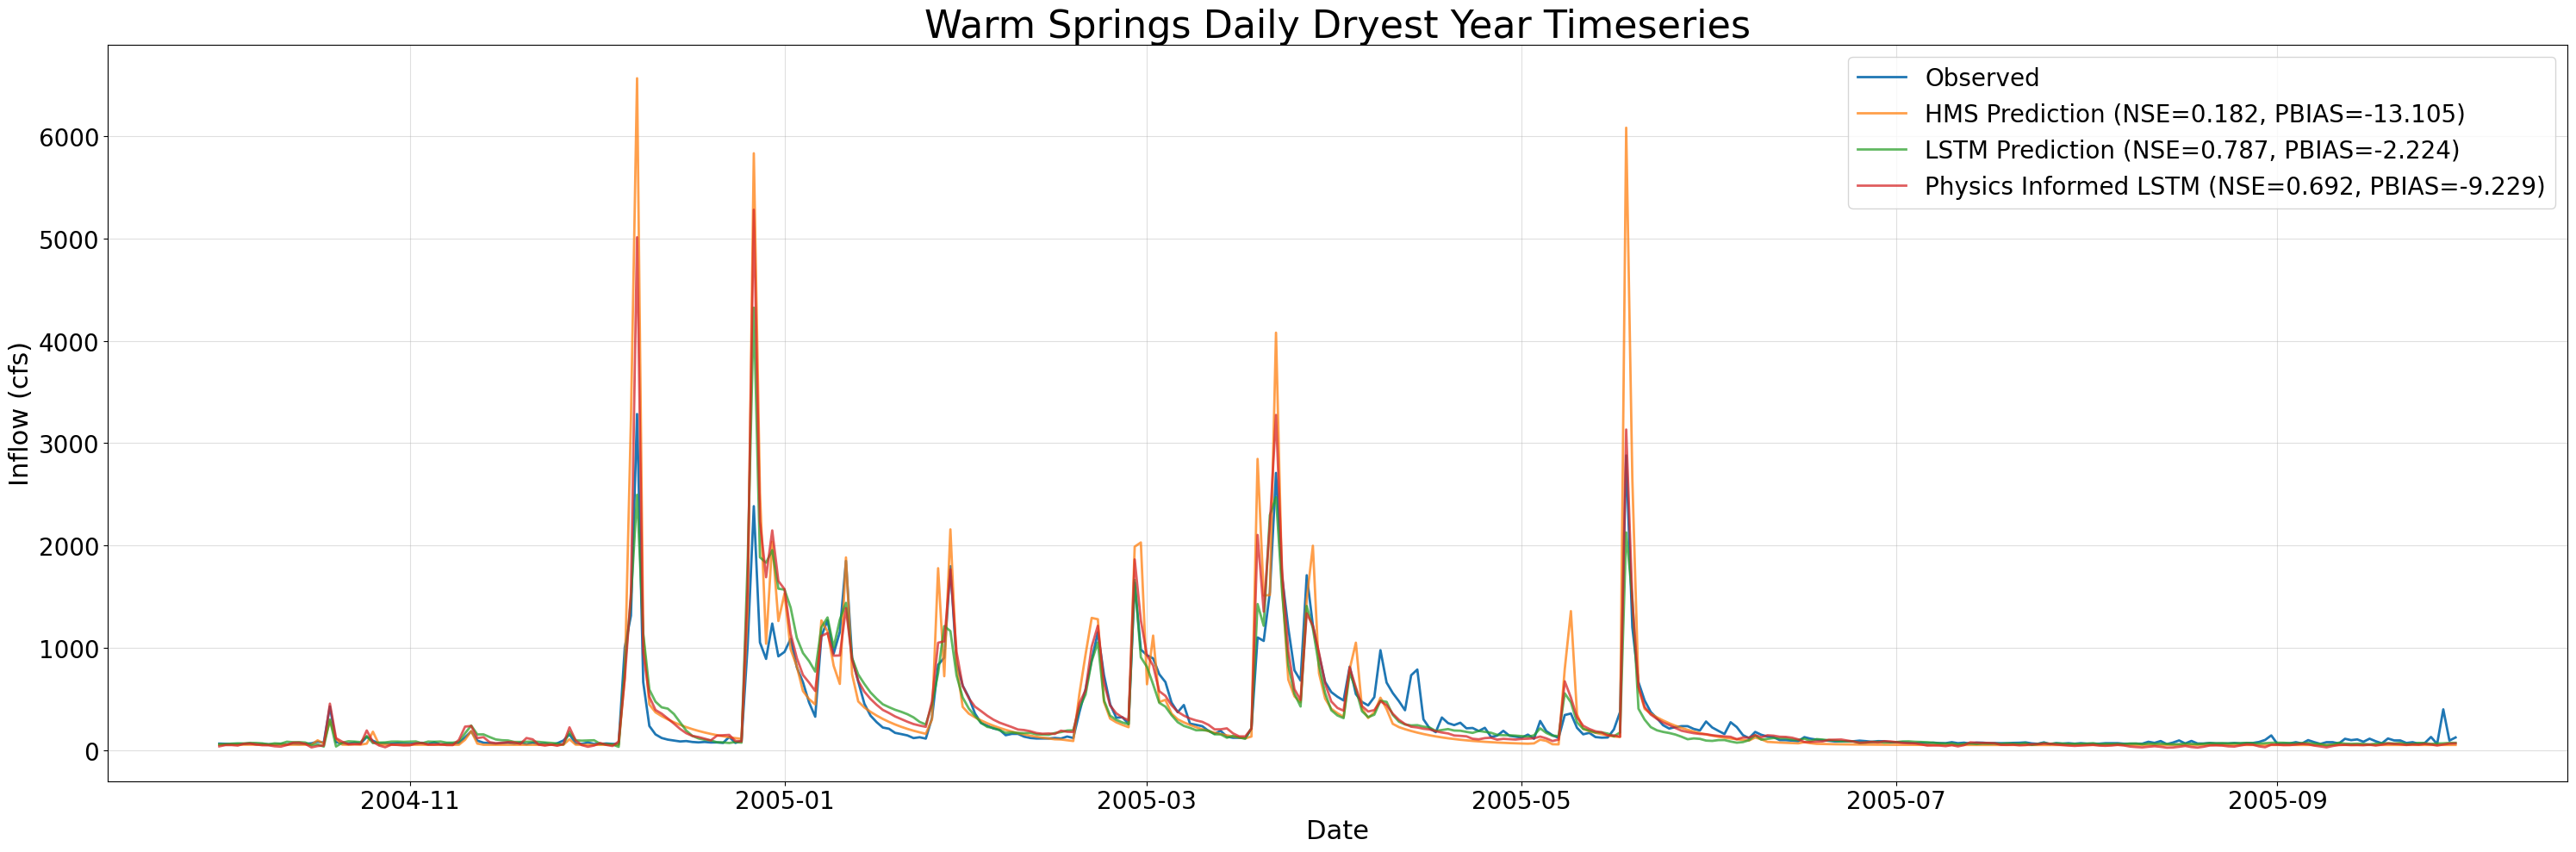

In [36]:
if not skip_best_model_validation:
    plot_timeseries_comparison(source=(no_physics_val_csv, physics_val_csv, path_to_physics_data), title="Warm Springs Daily Dryest Year Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_val, end_date=dryest_end_val, metrics_out="warm_springs_daily_val_dry_metrics.csv", ts_out="warm_springs_daily_val_dry_combined_ts.csv", fig_out="warm_springs_daily_val_dry_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_val, title="Warm Springs Daily Dryest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_val, end_date=dryest_end_val, metrics_out="warm_springs_daily_val_dry_metrics.csv", ts_out="warm_springs_daily_val_dry_combined_ts.csv", fig_out="warm_springs_daily_val_dry_model_comparison.png", legend_font=20, axis_font=22)

HMS
  NSE = -0.151
  PBIAS = -33.808
LSTM
  NSE = 0.174
  PBIAS = -37.155
PILSTM
  NSE = 0.352
  PBIAS = -44.252


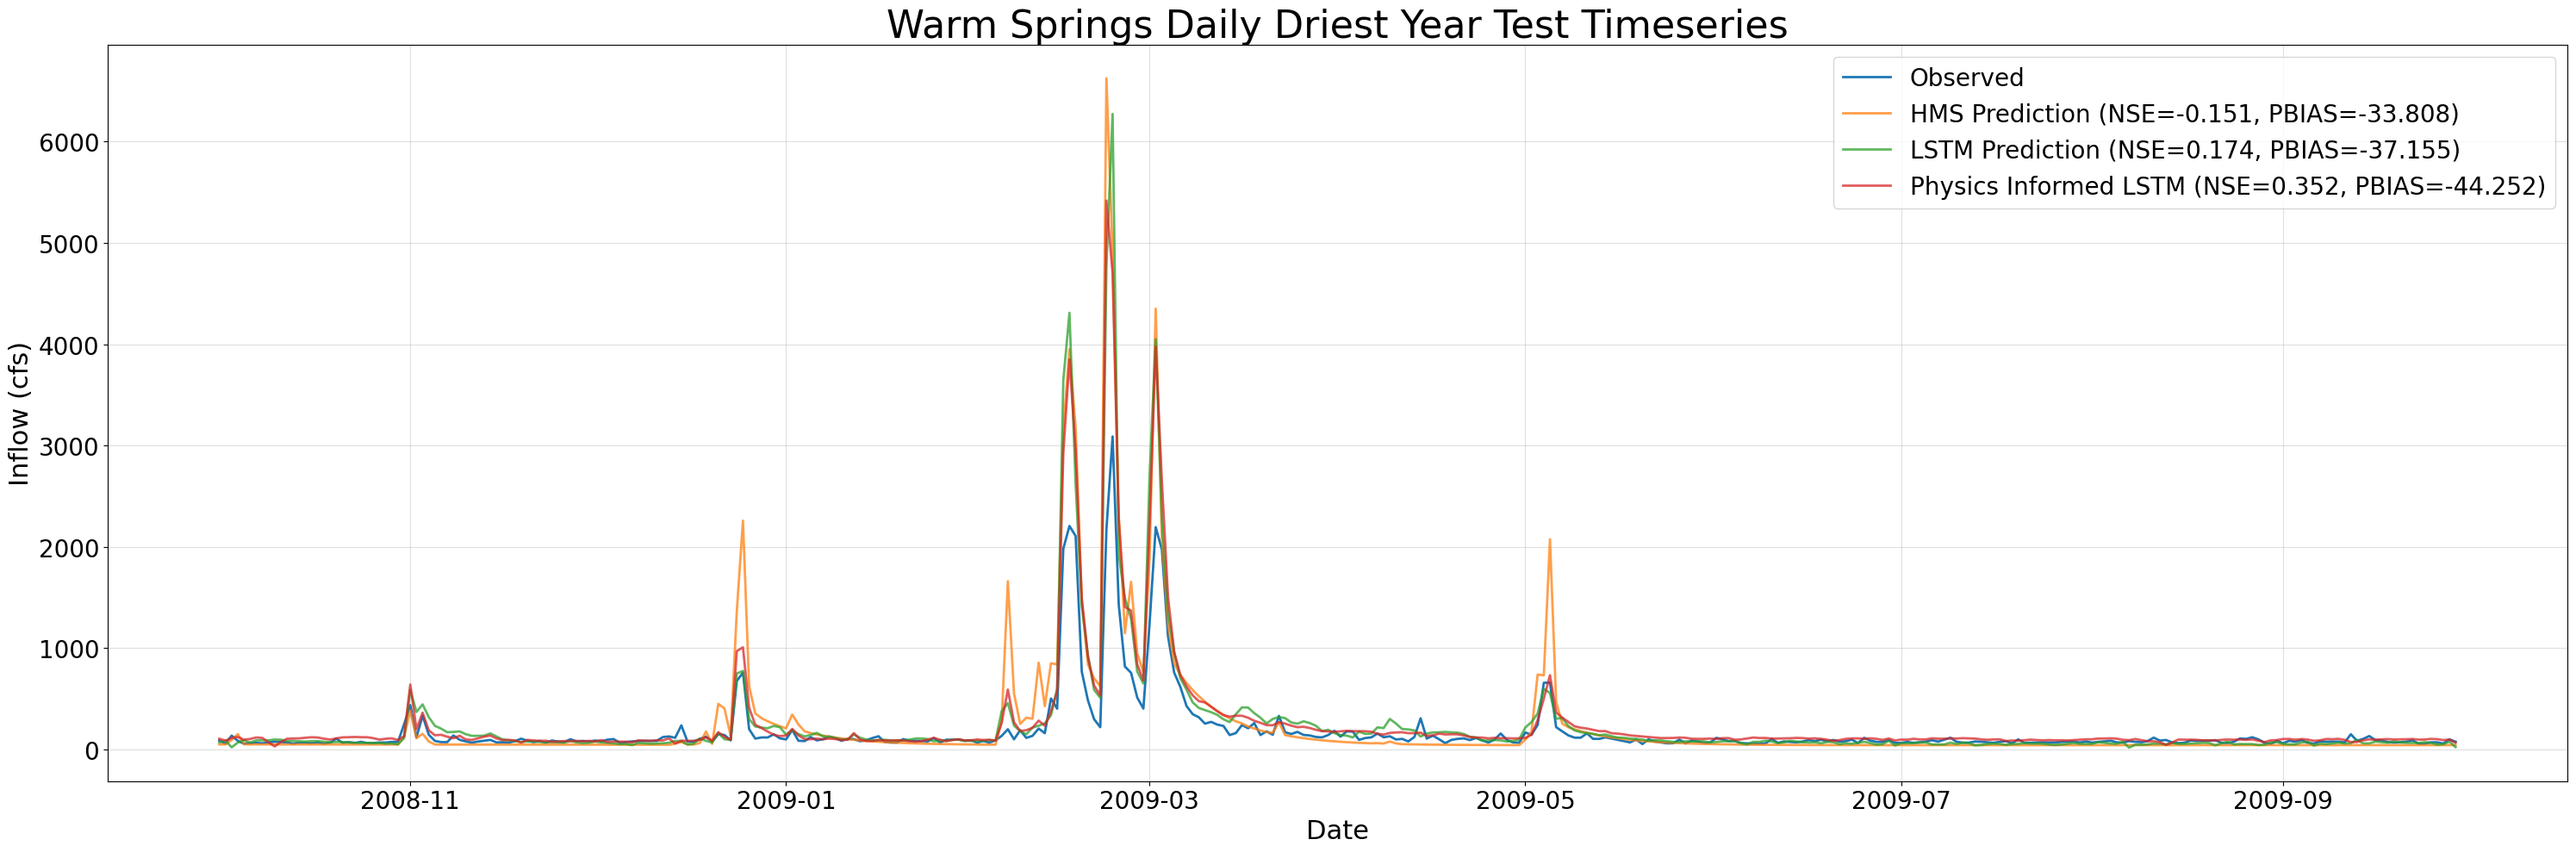

In [37]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv, physics_test_csv, path_to_physics_data), title="Warm Springs Daily Driest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="warm_springs_daily_test_dry_metrics.csv", ts_out="warm_springs_daily_test_dry_combined_ts.csv", fig_out="warm_springs_daily_test_dry_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df, title="Warm Springs Daily Driest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="warm_springs_daily_test_dry_metrics.csv", ts_out="warm_springs_daily_test_dry_combined_ts.csv", fig_out="warm_springs_daily_test_dry_model_comparison.png", legend_font=20, axis_font=22)

In [38]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv, physics_test_csv, path_to_physics_data), title="Warm Springs Daily Driest Year Test Timeseries – Interactive", backend="plotly", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="warm_springs_daily_test_dry_metrics.csv", ts_out="warm_springs_daily_test_dry_combined_ts.csv", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df, title="Warm Springs Daily Driest Year Test Timeseries – Interactive", backend="plotly", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="warm_springs_daily_test_dry_metrics.csv", ts_out="warm_springs_daily_test_dry_combined_ts.csv", legend_font=12, axis_font=22)

HMS
  NSE = -0.151
  PBIAS = -33.808
LSTM
  NSE = 0.174
  PBIAS = -37.155
PILSTM
  NSE = 0.352
  PBIAS = -44.252


##### Gridded Timeseries Plots - Validation & Testing

In [39]:
if not skip_best_model_validation:
    ts_triptych_v3((no_physics_val_csv, physics_val_csv, path_to_physics_data),wet_start=wettest_start_val, wet_end=wettest_end_val, dry_start=dryest_start_val, dry_end=dryest_end_val, save_path="warm_springs_daily_TS_validation.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d-%b-%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title="Warm Springs Daily Validation Period Timeseries Across Models", main_title_font=14, main_title_y=0.99, main_title_pad=0.05, row_titles=("Full Validation period","Most-wet water-year","Most-dry water-year"))

else:
    ts_triptych_v3(combined_df_val, wet_start=wettest_start_val, wet_end=wettest_end_val, dry_start=dryest_start_val, dry_end=dryest_end_val, save_path="warm_springs_daily_TS_validation.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d‑%b‑%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title = "Warm Springs Daily Validation Timeseries Across Models", main_title_font=14, main_title_y = 0.99, main_title_pad = 0.05, row_titles=("Full validation period", "Most‑wet water‑year", "Most‑dry water‑year"))

In [40]:
if not skip_best_model_test:
    ts_triptych_v3((no_physics_test_csv, physics_test_csv, path_to_physics_data), wet_start=wettest_start_test, wet_end=wettest_end_test, dry_start=dryest_start_test, dry_end=dryest_end_test, save_path="warm_springs_daily_TS_testing.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d-%b-%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title="Warm Springs Daily Test Period Timeseries Across Models", main_title_font=14, main_title_y=0.99, main_title_pad=0.05, row_titles=("Full Testing period","Most-wet water-year","Most-dry water-year"))
    
else:
    ts_triptych_v3(combined_df, wet_start=wettest_start_test, wet_end=wettest_end_test, dry_start=dryest_start_test, dry_end=dryest_end_test, save_path="warm_springs_daily_TS_testing.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d‑%b‑%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title = "Warm Springs Daily Test Period Timeseries Across Models", main_title_font=14, main_title_y = 0.99, main_title_pad = 0.05, row_titles=("Full Testing period", "Most‑wet water‑year", "Most‑dry water‑year"))

##### Gridded Scatter Plots - Testing

In [41]:
if not skip_best_model_test:
    scatter_pngs = scatter_triptych_pngs_v3((no_physics_test_csv, physics_test_csv, path_to_physics_data), wet_start = wettest_start_test, wet_end = wettest_end_test, dry_start = dryest_start_test,  dry_end = dryest_end_test, out_dir = "warm_springs_daily_scatter", layout = "horizontal", square_side  = 4.5, legend_font  = 16, axis_font = 16, point_size = 28, top_pad = .90, suptitle_y = 1.04, dpi = 600, row_titles = ("Warm Springs Daily – Full test period", "Warm Springs Daily – Wettest water‑year", "Warm Springs Daily – Driest water‑year"), resolution = "daily")
    
else:
    scatter_pngs = scatter_triptych_pngs_v3(combined_df, wet_start = wettest_start_test, wet_end = wettest_end_test, dry_start = dryest_start_test,  dry_end = dryest_end_test, out_dir = "warm_springs_daily_scatter", layout = "horizontal", square_side  = 4.5, legend_font  = 16, axis_font = 16, point_size = 28, top_pad = .90, suptitle_y = 1.04, dpi = 600, row_titles = ("Warm Springs Daily – Full test period", "Warm Springs Daily – Wettest water‑year", "Warm Springs Daily – Driest water‑year"), resolution = "daily")